In [1]:
from torchvision import datasets
import torch
data_folder = '~/data/FMNIST' # define o local

# baixa e carrega o dataset de treino do FashionMNIST
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

# separa os dados brutos
tr_images = fmnist.data
tr_targets = fmnist.targets

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.9MB/s]


In [2]:
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data # extrai os pixels
val_targets = val_fmnist.targets # extrai os rótulos

In [3]:
# Importa as ferramentas essenciais
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import SGD, Adam
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() # converte os dados brutos para o tipo float
        x = x.view(-1, 28*28)/255 # escala os valores de pixel
        self.x, self.y = x, y # armazena as imagens

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix] # recupera uma imagem
        return x.to(device), y.to(device) # envia os dados para o hardware


    def __len__(self):
        return len(self.x) # retorna a quantidade

In [6]:
def get_model():
    # Define a arquitetura
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000), # camada de entrada
        nn.ReLU(), # ativação ReLU
        nn.Linear(1000, 1000), # camada oculta
        nn.ReLU(), # segunda ativação ReLU
        nn.Linear(1000, 10) # Camada de Saída
    ).to(device)

    loss_fn = nn.CrossEntropyLoss() # Define a função de perdar
    optimizer = Adam(model.parameters(), lr=1e-3) # define o otimizador
    return model, loss_fn, optimizer # retorna o pacote

In [7]:
def train_batch(x, y, model, opt, loss_fn):
    model.train() # coloca o modelo em treino
    prediction = model(x) # passa os dados pelo modelo
    batch_loss = loss_fn(prediction, y) # calcula o erro comparando a previsao
    batch_loss.backward() # calcula os gradientes
    optimizer.step()# atualiza os pesos do modelo
    optimizer.zero_grad() # limpa os gradientes
    return batch_loss.item() # retorna o valor numerico

def accuracy(x, y, model):
    model.eval() # coloca o modelo em modo de avaliação

    with torch.no_grad():# desativa o cálculo
        prediction = model(x)# gera as previsos
    max_values, argmaxes = prediction.max(-1)# pega o índice
    is_correct = argmaxes == y # compara se a escolha
    return is_correct.cpu().numpy().tolist()# retorna uma lista de valores

In [8]:
torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x) # faz a previsao
    val_loss = loss_fn(prediction, y) # calcula o erro
    return val_loss.item() # retorna o valor

In [9]:
def get_data():
    # Prepara os dados de treino
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    # prepara os dados de validação e carrega
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl # retorna os carregadores de dados

In [10]:
# Executa as funçoes
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

In [11]:
# Inicializa listas vazias
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch) # mostra a rodada
    train_epoch_losses, train_epoch_accuracies = [], []# listas temporarias
    for ix, batch in enumerate(iter(trn_dl)): # passa por tudo
        x, y = batch # Pega as imagens e os rótulos corretos
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean() # calcula a media

    # verifica o quanto o modelo aprendeu
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model) # Verifica acertos/erros
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies) # calcula a media


    # testa o modelo com dados que ele nunca viu
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model) # Mede a precisão na validação
        validation_loss = val_loss(x, y, model) # Mede o erro na validação

    # Calcula a média de acerto da validação
    val_epoch_accuracy = np.mean(val_is_correct)

    # Guarda todos os resultados médios nas listas
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4


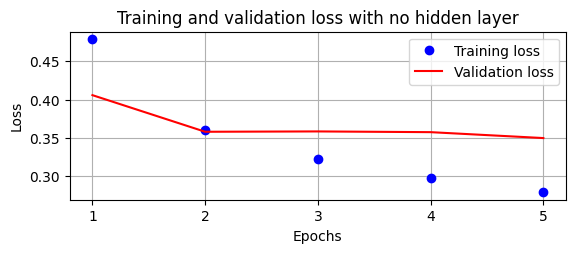

/tmp/ipykernel_14291/1890947205.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


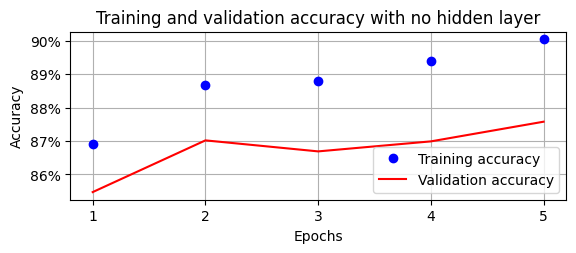

In [12]:
epochs = np.arange(5) + 1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with no hidden layer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with no hidden layer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.grid(True)
plt.legend()
plt.show()